## Benckmark Visualization

In [62]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def parse_benchmark_log(filename):
    cases = []
    times = []
    gflops = []
    intensities = []
    Ms = []
    Ns = []
    Ks = []

    with open(filename, 'r') as f:
        content = f.read()

    pattern = re.compile(
        r"Running (\w+) with M=(\d+) N=(\d+) K=(\d+).*?"
        r"Custom FP16 Kernel Time: ([\d\.]+) ms, gFLOPS: ([\d\.]+)",
        re.DOTALL
    )

    for match in pattern.finditer(content):
        case_name = match.group(1)
        M = int(match.group(2))
        N = int(match.group(3))
        K = int(match.group(4))
        time_ms = float(match.group(5))
        gflops_val = float(match.group(6))

        flops = 2 * M * N * K
        mem_bytes = 2 * (M * K + K * N + M * N)
        intensity = flops / mem_bytes

        cases.append(case_name)
        Ms.append(M)
        Ns.append(N)
        Ks.append(K)
        times.append(time_ms)
        gflops.append(gflops_val)
        intensities.append(intensity)

    return cases, times, gflops, intensities, Ms, Ns, Ks


# def log_results(cases, Ms, Ns, Ks, times, gflops, intensities):
#     print(f"{'Case':<10} {'M':>6} {'N':>6} {'K':>6} {'Time (ms)':>12} {'GFLOPS':>10} {'Intensity (FLOPs/byte)':>24}")
#     print("-"*80)
#     for i in range(len(cases)):
#         print(f"{cases[i]:<10} {Ms[i]:6} {Ns[i]:6} {Ks[i]:6} "
#               f"{times[i]:12.4f} {gflops[i]:10.2f} {intensities[i]:24.2f}")
def log_results(cases, Ms, Ns, Ks, times, gflops, intensities):
    # 表头
    print("| Case      |     M |     N |     K |   Time (ms) |    GFLOPS | Intensity (FLOPs/byte) |")
    print("|:---------:|-----:|-----:|-----:|------------:|---------:|-----------------------:|")
    
    # 表格内容
    for i in range(len(cases)):
        print(f"| {cases[i]:<9} | {Ms[i]:5} | {Ns[i]:5} | {Ks[i]:5} | {times[i]:10.4f} | {gflops[i]:8.2f} | {intensities[i]:23.2f} |")



def plot_benchmark(cases, times, gflops, intensities):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax2 = ax1.twinx()
    ax3 = ax1.twinx()

    x = range(len(cases))
    bar_width = 0.35

    ax3.spines['right'].set_position(('outward', 60))

    ax1.bar(x, times, width=bar_width, color='tab:blue', label='Time (ms)')
    ax2.bar([i + bar_width for i in x], gflops, width=bar_width, color='tab:orange', label='GFLOPS')
    ax3.plot([i + bar_width/2 for i in x], intensities, color='tab:green', marker='o', label='Compute Intensity (FLOPs/byte)', linewidth=2)

    ax1.set_xlabel('Test Case')
    ax1.set_xticks([i + bar_width/2 for i in x])
    ax1.set_xticklabels(cases, rotation=45, ha='right')

    ax1.set_ylabel('Time (ms)', color='tab:blue')
    ax2.set_ylabel('GFLOPS', color='tab:orange')
    ax3.set_ylabel('Compute Intensity\n(FLOPs/byte)', color='tab:green')

    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax3.tick_params(axis='y', labelcolor='tab:green')

    ax1.set_yscale('log')
    ax2.set_yscale('log')
    ax3.set_yscale('log')

    ax1.set_title('Benchmark Results: Time, GFLOPS, and Compute Intensity')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    h3, l3 = ax3.get_legend_handles_labels()
    ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc='upper left')

    plt.tight_layout()
    plt.show()

def plot_benchmark_seaborn(cases, times, gflops, intensities):
    sns.set(style='white', palette="Set2", color_codes=False)
    sns.set_style("ticks")
    colors = sns.color_palette()

    # 归一化
    times_norm = np.array(times) / max(times)
    gflops_norm = np.array(gflops) / max(gflops)
    intensities_norm = np.array(intensities) / max(intensities)

    x = np.arange(len(cases))
    bar_width = 0.35

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # 左轴画时间柱状图（归一化，越小越好）
    bars1 = ax1.bar(x, times, bar_width, label='Time', color=colors[0], edgecolor='black')
    ax1.set_ylabel('Time',  fontsize=18)
    ax1.tick_params(axis='y', labelcolor=colors[0])
    # ax1.set_ylim(0, 1.1)
    ax1.set_xticks(x)
    ax1.set_xticklabels(cases, rotation=45, ha='right', fontsize=14)

    # 右轴画 GFLOPS 柱状图（归一化，越大越好）
    ax2 = ax1.twinx()
    bars2 = ax2.bar(x + bar_width, gflops, bar_width, label='GFLOPS', color=colors[1], edgecolor='black')
    ax2.set_ylabel('GFLOPS',  fontsize=18)
    ax2.tick_params(axis='y', labelcolor=colors[1])
    # ax2.set_ylim(0, 1.1)

    # 同轴右边画计算强度折线，颜色同 GFLOPS
    ax2.plot(x + bar_width/2, intensities, color=colors[2], marker='o', label='Compute Intensity', linewidth=2)
    
    # 标题
    ax1.set_title('Benchmark Results: Time and GFLOPS with Compute Intensity', fontsize=18)

    # log
    ax1.set_yscale('log')
    ax2.set_yscale('log')

    # 图例合并
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    # 图例
    ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=14, frameon=True)

    sns.despine()
    plt.tight_layout()
    # save as PNG
    # plt.savefig('benchmark_results.png', dpi=300, bbox_inches='tight')
    # save as PDF
    # plt.savefig('benchmark_results.pdf', bbox_inches='tight')
    # show plot
    plt.show()


In [63]:
logfile = "../logs/benchmark.log"  # 你的日志文件路径
cases, times, gflops, intensities, Ms, Ns, Ks = parse_benchmark_log(logfile)

In [64]:
log_results(cases, Ms, Ns, Ks, times, gflops, intensities)

| Case      |     M |     N |     K |   Time (ms) |    GFLOPS | Intensity (FLOPs/byte) |
|:---------:|-----:|-----:|-----:|------------:|---------:|-----------------------:|
| Case1     |   768 |   768 |   768 |     0.6025 |  1503.56 |                  256.00 |
| Case2     |   128 |  1024 |  2048 |     0.4701 |  1142.15 |                  107.79 |
| Case3     |   128 |  2048 |  8192 |     2.5943 |  1655.51 |                  118.72 |
| Case4     |   512 |  3072 |  1024 |     1.6651 |  1934.53 |                  307.20 |
| Case5     |   512 |  4096 |  8192 |    15.5674 |  2207.15 |                  431.16 |
| Case6     |  3136 |   576 |    64 |     0.2759 |   838.06 |                   56.56 |
| Case7     |  4096 |  4096 |  4096 |    60.3260 |  2278.27 |                 1365.33 |
| Case8     |  1024 | 16384 | 16384 |   249.4680 |  2203.72 |                  910.22 |
| Case9     |  4096 | 16384 | 14336 |   870.1650 |  2211.24 |                 2667.16 |
| Case10    | 32768 | 32768 | 3276

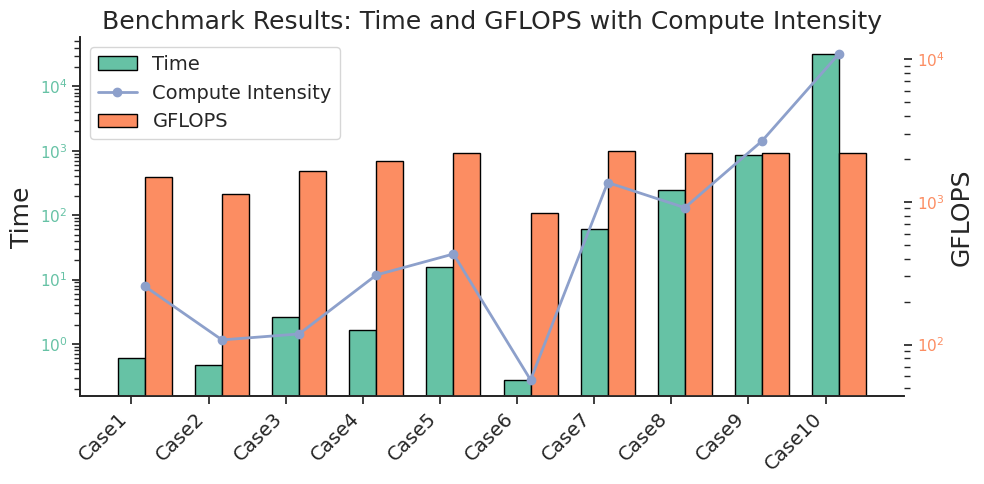

In [65]:
plot_benchmark_seaborn(cases, times, gflops, intensities)

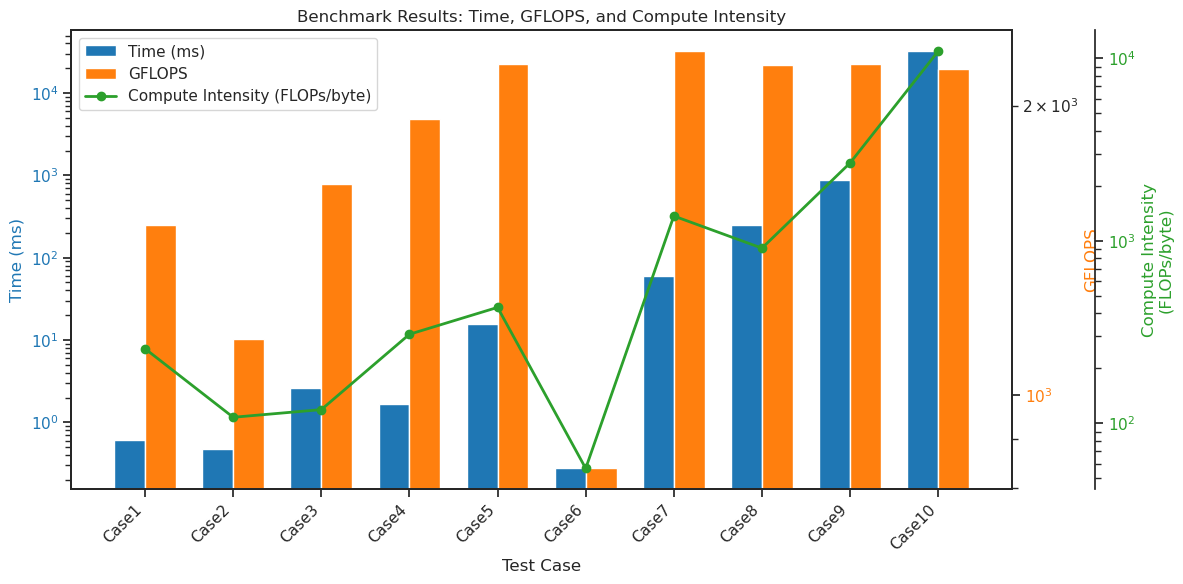

In [66]:
plot_benchmark(cases, times, gflops, intensities)

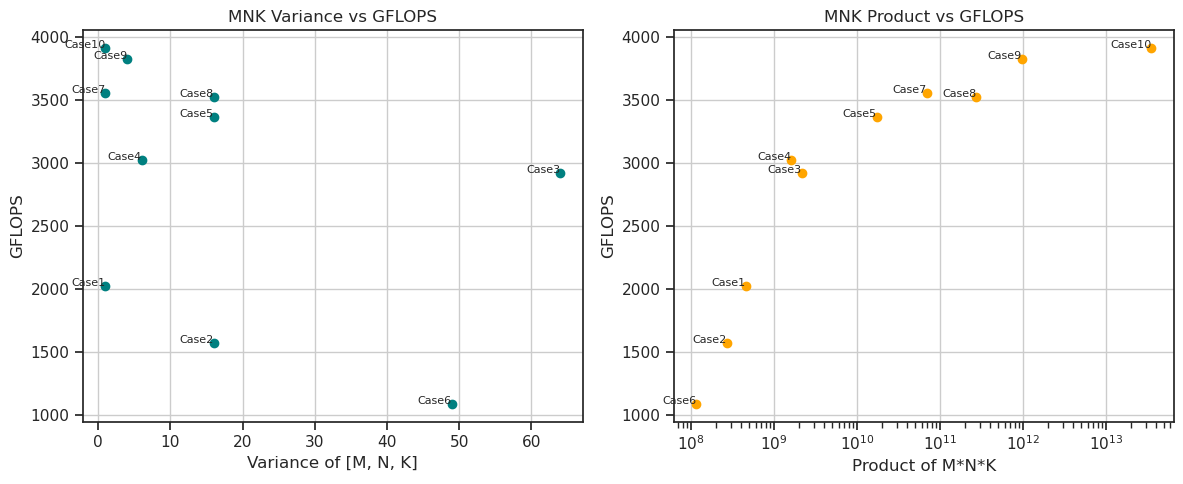

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# 表中数据
cases = [
    {"case": "Case1",  "M": 768,   "N": 768,   "K": 768,   "GFLOPS": 2022.25},
    {"case": "Case2",  "M": 128,   "N": 1024,  "K": 2048,  "GFLOPS": 1566.71},
    {"case": "Case3",  "M": 128,   "N": 2048,  "K": 8192,  "GFLOPS": 2919.71},
    {"case": "Case4",  "M": 512,   "N": 3072,  "K": 1024,  "GFLOPS": 3020.44},
    {"case": "Case5",  "M": 512,   "N": 4096,  "K": 8192,  "GFLOPS": 3368.41},
    {"case": "Case6",  "M": 3136,  "N": 576,   "K": 64,    "GFLOPS": 1086.31},
    {"case": "Case7",  "M": 4096,  "N": 4096,  "K": 4096,  "GFLOPS": 3556.08},
    {"case": "Case8",  "M": 1024,  "N": 16384, "K": 16384, "GFLOPS": 3520.50},
    {"case": "Case9",  "M": 4096,  "N": 16384, "K": 14336, "GFLOPS": 3826.50},
    {"case": "Case10", "M": 32768, "N": 32768, "K": 32768, "GFLOPS": 3911.76},
]

# 计算 MNK 方差和 MNK 乘积
variances = []
products = []
gflops = []
labels = []

for c in cases:
    mnk = np.array([c["M"], c["N"], c["K"]])
    var = np.max(mnk) / np.min(mnk)
    prod = np.prod(mnk)
    variances.append(var)
    products.append(prod)
    gflops.append(c["GFLOPS"])
    labels.append(c["case"])

# 绘图
plt.figure(figsize=(12,5))

# 子图1: MNK 方差 vs GFLOPS
plt.subplot(1,2,1)
plt.scatter(variances, gflops, color='teal')
for i, label in enumerate(labels):
    plt.text(variances[i], gflops[i], label, fontsize=8, ha='right')
plt.xlabel('Variance of [M, N, K]')
plt.ylabel('GFLOPS')
plt.title('MNK Variance vs GFLOPS')
# plt.xscale('log')
# plt.yscale('log')
plt.grid(True)

# 子图2: MNK 乘积 vs GFLOPS
plt.subplot(1,2,2)
plt.scatter(products, gflops, color='orange')
for i, label in enumerate(labels):
    plt.text(products[i], gflops[i], label, fontsize=8, ha='right')
plt.xlabel('Product of M*N*K')
plt.ylabel('GFLOPS')
plt.title('MNK Product vs GFLOPS')
# log x 
plt.xscale('log')
plt.grid(True)

plt.tight_layout()
plt.show()
